# FicZon Incorporated Client 

## Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import mysql.connector
import warnings

warnings.filterwarnings('ignore')


## Connect to MySQL Database

In [2]:
conn = mysql.connector.connect(
    host='18.136.157.135',
    user='dm_team2',
    password='DM!$Team&27@9!20!',
    database='project_sales',
    port=3306
)


## Load Data from Database

In [3]:
query = "SELECT * FROM data"
df = pd.read_sql(query, conn)


In [4]:
df.shape

(7422, 9)

## Initial Data Observations
1) The dataset contains 7422 records and 9 columns

2) Target variable Status has two classes: High Potential and Low Potential

3) The dataset contains missing values, mainly in:
    Mobile, Product_ID, Location, Sales_Agent

4) No critical data corruption observed

## Basic Dataset Inspection

In [5]:
df.head()

,Created,Product_ID,Source,Mobile,EMAIL,Sales_Agent,Location,Delivery_Mode,Status
0,14-11-2018 10:05,,Website,984XXXXXXX,aXXXXXXX@gmail.com,Sales-Agent-11,,Mode-5,Open
1,14-11-2018 09:22,,Website,XXXXXXX,#VALUE!,Sales-Agent-10,,Mode-5,Open
2,14-11-2018 09:21,,Website,XXXXXXX,dXXXXXXX@yahoo.com,Sales-Agent-10,,Mode-5,Open
3,14-11-2018 08:46,,Website,XXXXXXX,wXXXXXXX@gmail.com,Sales-Agent-10,,Mode-5,Open
4,14-11-2018 07:34,,Website,XXXXXXX,cXXXXXXX@gmail.com,Sales-Agent-10,,Mode-5,Open


In [6]:
df.tail()

,Created,Product_ID,Source,Mobile,EMAIL,Sales_Agent,Location,Delivery_Mode,Status
7417,28-04-2018 09:45,9,Call,,aXXXXXXX@gmail.com,Sales-Agent-6,Mumbai,Mode-4,LOST
7418,28-04-2018 09:43,15,Call,,#VALUE!,Sales-Agent-12,Other Locations,Mode-5,LOST
7419,28-04-2018 09:20,5,Live Chat-Direct,,sXXXXXXX@gmail.com,Sales-Agent-11,Bangalore,Mode-1,Not Responding
7420,28-04-2018 08:04,21,CRM form,,YXXXXXXX@gmail.com,Sales-Agent-4,Other Locations,Mode-1,Just Enquiry
7421,28-04-2018 07:54,25,Website,,cXXXXXXX@gmail.com,Sales-Agent-3,Chennai,Mode-1,CONVERTED


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7422 entries, 0 to 7421
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Created        7422 non-null   object
 1   Product_ID     7422 non-null   object
 2   Source         7422 non-null   object
 3   Mobile         7422 non-null   object
 4   EMAIL          7422 non-null   object
 5   Sales_Agent    7422 non-null   object
 6   Location       7422 non-null   object
 7   Delivery_Mode  7422 non-null   object
 8   Status         7422 non-null   object
dtypes: object(9)
memory usage: 522.0+ KB


In [8]:
df.isnull().sum()

Created          0
Product_ID       0
Source           0
Mobile           0
EMAIL            0
Sales_Agent      0
Location         0
Delivery_Mode    0
Status           0
dtype: int64

## Duplicate Values Check 

In [9]:
df.duplicated().sum()

np.int64(2)

In [10]:
df = df.drop_duplicates()

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.to_csv("sales_data_cleaned.csv", index=False)
print("Cleaned dataset saved successfully")


Cleaned dataset saved successfully


In [13]:
df = pd.read_csv("sales_data_cleaned.csv") 
df.head()


,Created,Product_ID,Source,Mobile,EMAIL,Sales_Agent,Location,Delivery_Mode,Status
0,14-11-2018 10:05,NaN,Website,984XXXXXXX,aXXXXXXX@gmail.com,Sales-Agent-11,NaN,Mode-5,Open
1,14-11-2018 09:22,NaN,Website,XXXXXXX,#VALUE!,Sales-Agent-10,NaN,Mode-5,Open
2,14-11-2018 09:21,NaN,Website,XXXXXXX,dXXXXXXX@yahoo.com,Sales-Agent-10,NaN,Mode-5,Open
3,14-11-2018 08:46,NaN,Website,XXXXXXX,wXXXXXXX@gmail.com,Sales-Agent-10,NaN,Mode-5,Open
4,14-11-2018 07:34,NaN,Website,XXXXXXX,cXXXXXXX@gmail.com,Sales-Agent-10,NaN,Mode-5,Open


In [14]:
df.shape

(7420, 9)

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7420 entries, 0 to 7419
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Created        7420 non-null   object 
 1   Product_ID     7364 non-null   float64
 2   Source         7403 non-null   object 
 3   Mobile         5610 non-null   object 
 4   EMAIL          7420 non-null   object 
 5   Sales_Agent    7397 non-null   object 
 6   Location       7364 non-null   object 
 7   Delivery_Mode  7420 non-null   object 
 8   Status         7420 non-null   object 
dtypes: float64(1), object(8)
memory usage: 521.8+ KB


## Identify Target Variable

In [16]:
df['Status'].value_counts()


Status
Junk Lead               1536
Not Responding          1129
CONVERTED                834
Just Enquiry             760
Potential                708
Long Term                646
In Progress Positive     643
In Progress Negative     626
LOST                     440
Open                      80
converted                 18
Name: count, dtype: int64

## Feature Audit Drop Unwanted Columns 

In [17]:
df = df.drop(columns=['EMAIL', 'Mobile', 'Product_ID'])


## Handle Date Column

In [18]:
df['Created'] = pd.to_datetime(df['Created'], errors='coerce')

df['Created_Year'] = df['Created'].dt.year
df['Created_Month'] = df['Created'].dt.month

df = df.drop(columns=['Created'])


## Handle Missing Values

In [19]:
## Categorical → Mode
for col in df.select_dtypes(include='object').columns:
    df[col].fillna(df[col].mode()[0], inplace=True)


In [20]:
## Numerical → Median
for col in df.select_dtypes(include=np.number).columns:
    df[col].fillna(df[col].median(), inplace=True)


In [21]:
## REcheck 
df.isnull().sum()
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7420 entries, 0 to 7419
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Source         7420 non-null   object
 1   Sales_Agent    7420 non-null   object
 2   Location       7420 non-null   object
 3   Delivery_Mode  7420 non-null   object
 4   Status         7420 non-null   object
 5   Created_Year   7420 non-null   int32 
 6   Created_Month  7420 non-null   int32 
dtypes: int32(2), object(5)
memory usage: 347.9+ KB


## Intial Summary 
1) Loaded and inspected the dataset

2) Identified target variable

3) Removed identifier columns

4) Extracted year and month from date

5) Handled missing values safely

## Exploratory Data Analysis (EDA) & Feature Validation

### Target Variable Analysis

In [22]:
df['Status'].value_counts()
df['Status'].value_counts(normalize=True) * 100


Status
Junk Lead               20.700809
Not Responding          15.215633
CONVERTED               11.239892
Just Enquiry            10.242588
Potential                9.541779
Long Term                8.706199
In Progress Positive     8.665768
In Progress Negative     8.436658
LOST                     5.929919
Open                     1.078167
converted                0.242588
Name: proportion, dtype: float64

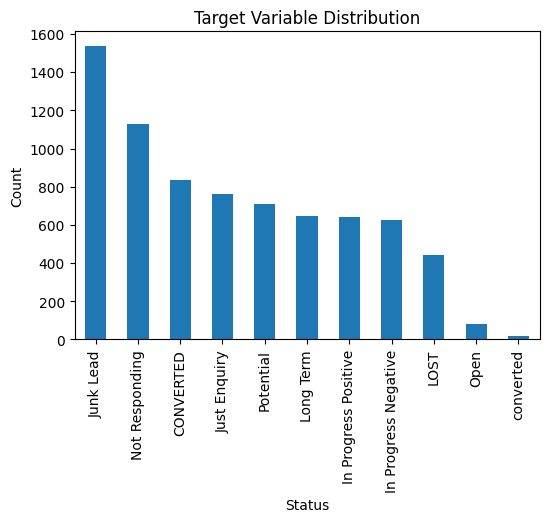

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
df['Status'].value_counts().plot(kind='bar')
plt.title("Target Variable Distribution")
plt.xlabel("Status")
plt.ylabel("Count")
plt.show()


### Separate Numerical & Categorical Features

In [24]:
# numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

numerical_cols = ['Created_Year', 'Created_Month']

df.select_dtypes(include='number').columns

categorical_cols = df.select_dtypes(include='object').columns

numerical_cols, categorical_cols


(['Created_Year', 'Created_Month'],
 Index(['Source', 'Sales_Agent', 'Location', 'Delivery_Mode', 'Status'], dtype='object'))

### Numerical Feature Distribution

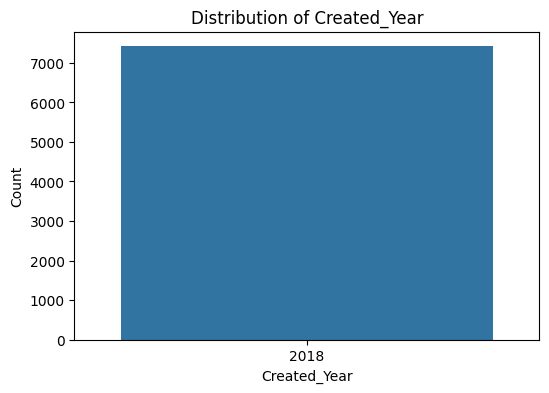

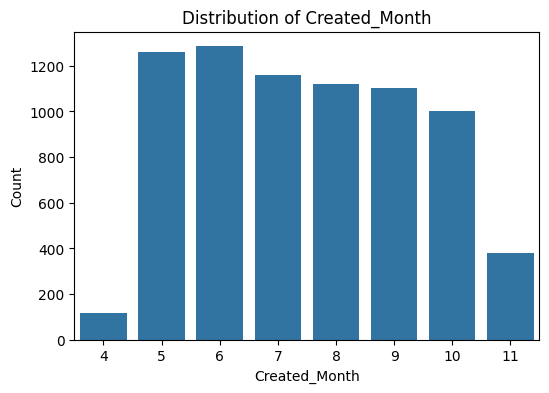

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

for col in numerical_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(x=df[col])
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.show()


### Scatter Plot (Numerical vs Target)

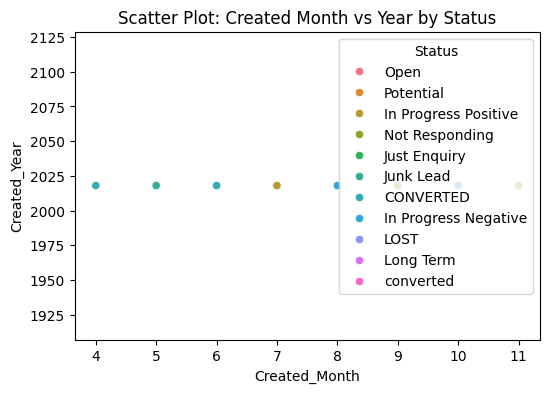

In [26]:
plt.figure(figsize=(6,4))
sns.scatterplot(
    x=df['Created_Month'],
    y=df['Created_Year'],
    hue=df['Status']
)
plt.title("Scatter Plot: Created Month vs Year by Status")
plt.show()


### Correlation Heatmap only numeric

In [27]:
numeric_df = df[['Created_Year', 'Created_Month']]



In [28]:
numeric_df

,Created_Year,Created_Month
0,2018,11
1,2018,11
2,2018,11
3,2018,11
4,2018,11
...,...,...
7415,2018,4
7416,2018,4
7417,2018,4
7418,2018,4


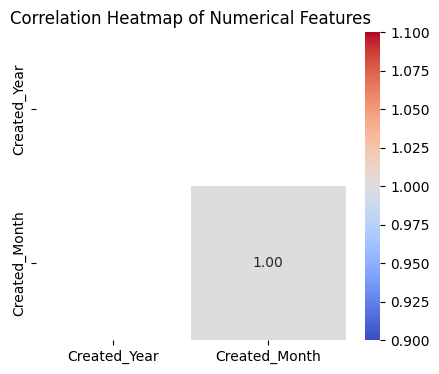

In [29]:
plt.figure(figsize=(5,4))
sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)
plt.title("Correlation Heatmap of Numerical Features")
plt.show()


### Categorical Feature Insight

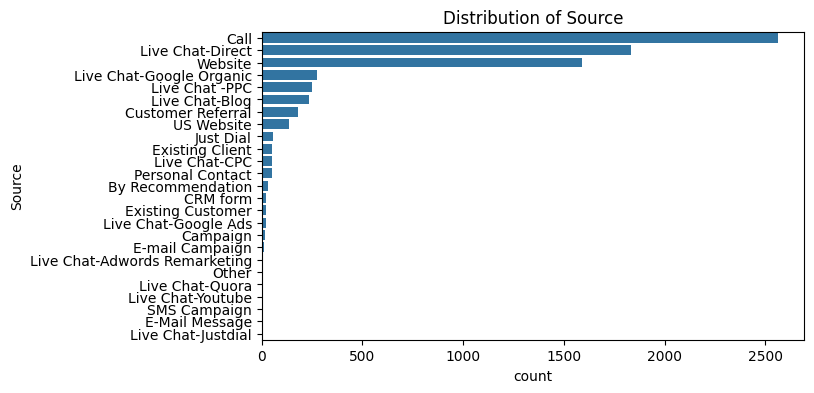

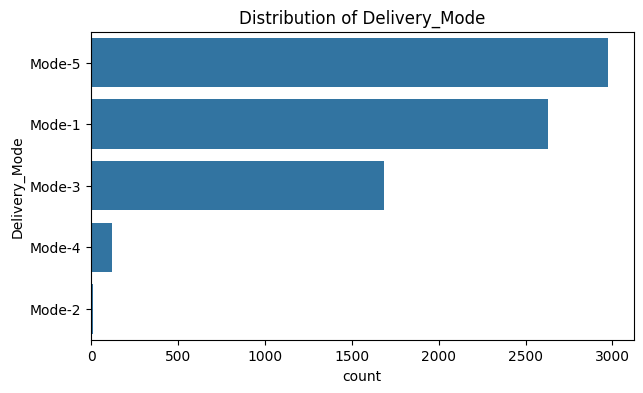

In [30]:
for col in ['Source', 'Delivery_Mode']:
    plt.figure(figsize=(7,4))
    sns.countplot(y=df[col], order=df[col].value_counts().index)
    plt.title(f'Distribution of {col}')
    plt.show()


### Outlier Check

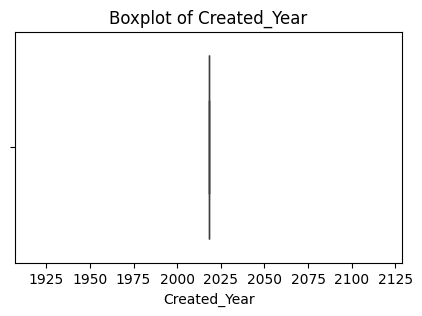

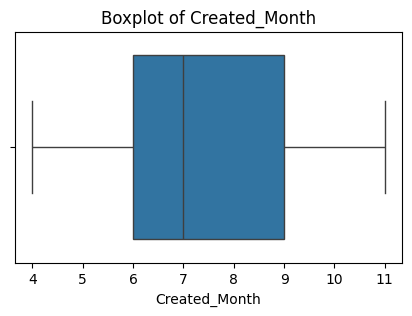

In [31]:
for col in numerical_cols:
    plt.figure(figsize=(5,3))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()


## EDA and Feature Validation Summary 
1) Checked target balance

2) Analyzed numerical feature distributions

3) Used scatter plot to visualize time patterns

4) Generated correlation heatmap

5) Validated categorical feature influence

6) Checked outliers without removal

## Feature Encoding & Baseline Models

### Separate Features & Target

In [32]:
X = df.drop('Status', axis=1)
y = df['Status']


### Encode Target Variable


In [33]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(y)


### Encode Categorical Features

In [34]:
## low_cardinality → One-Hot Encoding
low_cardinality = ['Source', 'Delivery_Mode']
X = pd.get_dummies(X, columns=low_cardinality, drop_first=True)


In [35]:
## High-cardinality → Frequency Encoding
high_cardinality = ['Sales_Agent', 'Location']

for col in high_cardinality:
    freq_map = X[col].value_counts(normalize=True)
    X[col] = X[col].map(freq_map)


In [36]:
## Final Feature Check
X.shape
X.dtypes

Sales_Agent                             float64
Location                                float64
Created_Year                              int32
Created_Month                             int32
Source_CRM form                            bool
Source_Call                                bool
Source_Campaign                            bool
Source_Customer Referral                   bool
Source_E-Mail Message                      bool
Source_E-mail Campaign                     bool
Source_Existing Client                     bool
Source_Existing Customer                   bool
Source_Just Dial                           bool
Source_Live Chat -PPC                      bool
Source_Live Chat-Adwords Remarketing       bool
Source_Live Chat-Blog                      bool
Source_Live Chat-CPC                       bool
Source_Live Chat-Direct                    bool
Source_Live Chat-Google Ads                bool
Source_Live Chat-Google Organic            bool
Source_Live Chat-Justdial               

## Train–Test Split

In [37]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.3,random_state=42,stratify=y)


In [38]:
X_train

,Sales_Agent,Location,Created_Year,Created_Month,Source_CRM form,Source_Call,Source_Campaign,Source_Customer Referral,Source_E-Mail Message,Source_E-mail Campaign,...,Source_Live Chat-Youtube,Source_Other,Source_Personal Contact,Source_SMS Campaign,Source_US Website,Source_Website,Delivery_Mode_Mode-2,Delivery_Mode_Mode-3,Delivery_Mode_Mode-4,Delivery_Mode_Mode-5
5115,0.160377,0.122507,2018,6,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
2911,0.105256,0.280863,2018,8,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
6543,0.191375,0.063477,2018,5,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1034,0.118464,0.280863,2018,10,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2641,0.052426,0.344474,2018,8,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1394,0.191375,0.063477,2018,9,False,False,False,False,False,False,...,False,False,False,False,False,True,False,True,False,False
1465,0.205256,0.344474,2018,9,False,False,False,False,False,False,...,False,False,False,False,False,True,False,True,False,False
4198,0.191375,0.071159,2018,7,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
4586,0.191375,0.071159,2018,7,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False


In [39]:
y_train

array([4, 0, 7, ..., 3, 3, 9], shape=(5194,))

## Feature Scaling 

In [40]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## Baseline Models

In [41]:
## Logistic Regression
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(C=0.1, max_iter=1000)
lr.fit(X_train_scaled, y_train)

print("LR Train:", lr.score(X_train_scaled, y_train))
print("LR Test :", lr.score(X_test_scaled, y_test))
print("LR Gap  :", lr.score(X_train_scaled, y_train) - lr.score(X_test_scaled, y_test))


LR Train: 0.2835964574509049
LR Test : 0.2780772686433064
LR Gap  : 0.005519188807598496


In [42]:
## Decision Tree
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    max_depth=5,
    min_samples_leaf=10,
    random_state=42
)
dt.fit(X_train, y_train)

print("DT Train:", dt.score(X_train, y_train))
print("DT Test :", dt.score(X_test, y_test))
print("DT Gap  :", dt.score(X_train, y_train) - dt.score(X_test, y_test))


DT Train: 0.3024643819792068
DT Test : 0.29469901168014373
DT Gap  : 0.007765370299063046


In [43]:
## KNN 
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=25)
knn.fit(X_train_scaled, y_train)

print("KNN Train:", knn.score(X_train_scaled, y_train))
print("KNN Test :", knn.score(X_test_scaled, y_test))
print("KNN Gap  :", knn.score(X_train_scaled, y_train) - knn.score(X_test_scaled, y_test))


KNN Train: 0.3457835964574509
KNN Test : 0.27403414195867026
KNN Gap  : 0.07174945449878062


## Overfitting Check Table

In [44]:
import pandas as pd

pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'KNN'],
    'Train Accuracy': [
        lr.score(X_train_scaled, y_train),
        dt.score(X_train, y_train),
        knn.score(X_train_scaled, y_train)
    ],
    'Test Accuracy': [
        lr.score(X_test_scaled, y_test),
        dt.score(X_test, y_test),
        knn.score(X_test_scaled, y_test)
    ],
    'Gap': [
        lr.score(X_train_scaled, y_train) - lr.score(X_test_scaled, y_test),
        dt.score(X_train, y_train) - dt.score(X_test, y_test),
        knn.score(X_train_scaled, y_train) - knn.score(X_test_scaled, y_test)
    ]
})


,Model,Train Accuracy,Test Accuracy,Gap
0,Logistic Regression,0.283596,0.278077,0.005519
1,Decision Tree,0.302464,0.294699,0.007765
2,KNN,0.345784,0.274034,0.071749


## Feature Encoding and Baseline Models Summary 
1) Applied correct encoding strategy

2) Avoided one-hot encoding for high-cardinality features

3) Built baseline machine learning models

4) Evaluated overfitting using train–test accuracy gap

## Advanced Models with hyperparameter tuning 

In [45]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=150,
    max_depth=8,
    min_samples_leaf=10,
    min_samples_split=10,
    random_state=42
)

rf.fit(X_train, y_train)

print("RF Train:", rf.score(X_train, y_train))
print("RF Test :", rf.score(X_test, y_test))
print("RF Gap  :", rf.score(X_train, y_train) - rf.score(X_test, y_test))


RF Train: 0.3242202541393916
RF Test : 0.2991913746630728
RF Gap  : 0.02502887947631882


In [46]:
### Random Forest Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV

rf_params = {
    'n_estimators': [100, 150],
    'max_depth': [6, 8],
    'min_samples_leaf': [10, 15]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_params,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

best_rf = rf_grid.best_estimator_

print("Best RF Params:", rf_grid.best_params_)
print("RF Train:", best_rf.score(X_train, y_train))
print("RF Test :", best_rf.score(X_test, y_test))
print("RF Gap  :", best_rf.score(X_train, y_train) - best_rf.score(X_test, y_test))


Best RF Params: {'max_depth': 8, 'min_samples_leaf': 10, 'n_estimators': 150}
RF Train: 0.3242202541393916
RF Test : 0.2991913746630728
RF Gap  : 0.02502887947631882


In [47]:
## Gradient Boosting
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gb.fit(X_train, y_train)

print("GB Train:", gb.score(X_train, y_train))
print("GB Test :", gb.score(X_test, y_test))
print("GB Gap  :", gb.score(X_train, y_train) - gb.score(X_test, y_test))


GB Train: 0.4033500192529842
GB Test : 0.33737646001796945
GB Gap  : 0.06597355923501474


In [48]:
## Gradient Boosting Tuning 
gb_params = {
    'n_estimators': [80, 100],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3]
}

gb_grid = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    gb_params,
    cv=3,
    scoring='accuracy'
)

gb_grid.fit(X_train, y_train)

best_gb = gb_grid.best_estimator_

print("Best GB Params:", gb_grid.best_params_)
print("GB Train:", best_gb.score(X_train, y_train))
print("GB Test :", best_gb.score(X_test, y_test))
print("GB Gap  :", best_gb.score(X_train, y_train) - best_gb.score(X_test, y_test))


Best GB Params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
GB Train: 0.4033500192529842
GB Test : 0.33737646001796945
GB Gap  : 0.06597355923501474


In [49]:
## Base SVM 
from sklearn.svm import SVC
svm = SVC(kernel='rbf', C=0.5, gamma='scale')

svm.fit(X_train_scaled, y_train)

print("SVM Train:", svm.score(X_train_scaled, y_train))
print("SVM Test :", svm.score(X_test_scaled, y_test))
print("SVM Gap  :", svm.score(X_train_scaled, y_train) - svm.score(X_test_scaled, y_test))


SVM Train: 0.2889872930304197
SVM Test : 0.27313566936208444
SVM Gap  : 0.015851623668335257


In [50]:
## SVM tuning 
svm_params = {
    'C': [0.1, 0.5, 1],
    'gamma': ['scale', 0.01],
    'kernel': ['rbf']
}

svm_grid = GridSearchCV(
    SVC(),
    svm_params,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

svm_grid.fit(X_train_scaled, y_train)

best_svm = svm_grid.best_estimator_

print("Best SVM Params:", svm_grid.best_params_)
print("SVM Train:", best_svm.score(X_train_scaled, y_train))
print("SVM Test :", best_svm.score(X_test_scaled, y_test))
print("SVM Gap  :", best_svm.score(X_train_scaled, y_train) - best_svm.score(X_test_scaled, y_test))


Best SVM Params: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
SVM Train: 0.29976896418944937
SVM Test : 0.279874213836478
SVM Gap  : 0.01989475035297139


In [51]:
## Overfit Camparion table 
pd.DataFrame({
    'Model': ['Random Forest', 'Gradient Boosting', 'SVM'],
    'Train Accuracy': [
        best_rf.score(X_train, y_train),
        best_gb.score(X_train, y_train),
        best_svm.score(X_train_scaled, y_train)
    ],
    'Test Accuracy': [
        best_rf.score(X_test, y_test),
        best_gb.score(X_test, y_test),
        best_svm.score(X_test_scaled, y_test)
    ],
    'Gap': [
        best_rf.score(X_train, y_train) - best_rf.score(X_test, y_test),
        best_gb.score(X_train, y_train) - best_gb.score(X_test, y_test),
        best_svm.score(X_train_scaled, y_train) - best_svm.score(X_test_scaled, y_test)
    ]
})


,Model,Train Accuracy,Test Accuracy,Gap
0,Random Forest,0.324220,0.299191,0.025029
1,Gradient Boosting,0.403350,0.337376,0.065974
2,SVM,0.299769,0.279874,0.019895


## Feature Importance Analysis

In [52]:
## feature importance for random forest 
rf_feature_importance = pd.Series(
    best_rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

rf_feature_importance

Location                                0.251034
Sales_Agent                             0.225746
Created_Month                           0.172292
Delivery_Mode_Mode-5                    0.099035
Source_Customer Referral                0.083454
Source_Call                             0.046730
Delivery_Mode_Mode-3                    0.029440
Source_Live Chat-Direct                 0.014778
Delivery_Mode_Mode-4                    0.014346
Source_Existing Client                  0.013760
Source_Website                          0.012800
Source_US Website                       0.012341
Source_Live Chat-Blog                   0.005852
Source_Live Chat -PPC                   0.004140
Source_Personal Contact                 0.004111
Source_Just Dial                        0.003633
Source_Existing Customer                0.003433
Source_Live Chat-Google Organic         0.002578
Source_Live Chat-CPC                    0.000315
Source_CRM form                         0.000092
Source_Campaign     

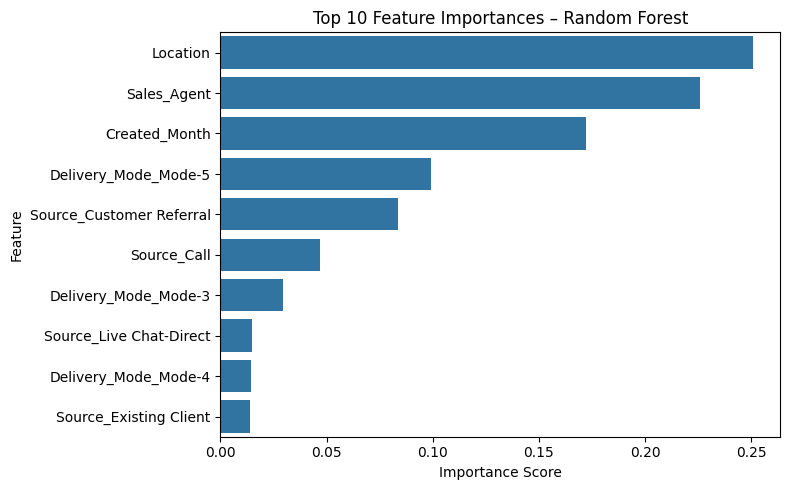

In [53]:

plt.figure(figsize=(8,5))
sns.barplot(
    x=rf_feature_importance.head(10),
    y=rf_feature_importance.head(10).index
)
plt.title("Top 10 Feature Importances – Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


In [54]:
## feature importance for Gradient Boosting
gb_feature_importance = pd.Series(
    best_gb.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

gb_feature_importance


Sales_Agent                             0.294398
Location                                0.245995
Created_Month                           0.168314
Source_Customer Referral                0.068398
Source_Call                             0.049222
Delivery_Mode_Mode-5                    0.045755
Source_Existing Client                  0.017642
Source_US Website                       0.010226
Delivery_Mode_Mode-4                    0.009300
Delivery_Mode_Mode-3                    0.008697
Source_Personal Contact                 0.008548
Source_Live Chat-Blog                   0.007941
Source_Existing Customer                0.007798
Source_Live Chat-Direct                 0.007758
Source_Website                          0.007494
Source_Live Chat-Google Organic         0.005967
Source_Live Chat -PPC                   0.005459
Source_Just Dial                        0.004639
Delivery_Mode_Mode-2                    0.003934
Source_CRM form                         0.003172
Source_Campaign     

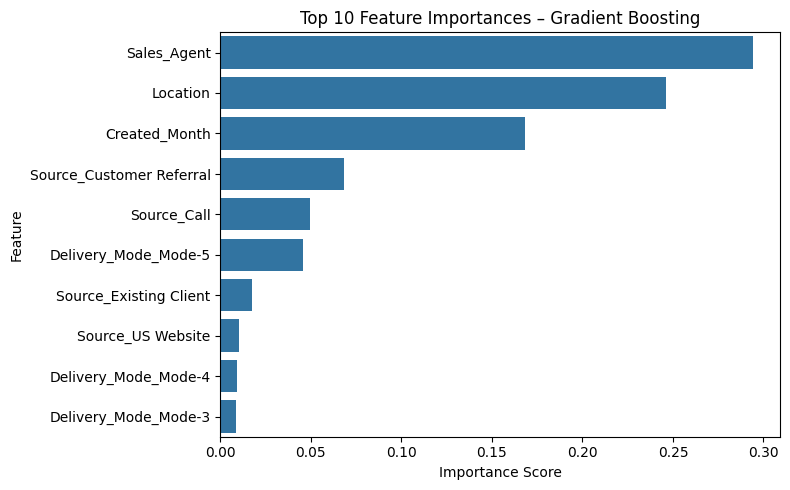

In [55]:
plt.figure(figsize=(8,5))
sns.barplot(
    x=gb_feature_importance.head(10),
    y=gb_feature_importance.head(10).index
)
plt.title("Top 10 Feature Importances – Gradient Boosting")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


## Advance , Hyperparameter Tuning and Feature Importance  Summary 
1) Built Random Forest , Gradient Boosting models, and SVM Models

2) Applied controlled hyperparameter tuning

3) Evaluated train–test accuracy gap

4) Performed Feature Importance Analysis using tree-based models


## Final Comparison table 

In [56]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score



In [57]:

final_results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'KNN',
        'Decision Tree',
        'Random Forest (Tuned)',
        'SVM (Tuned)',
        'Gradient Boosting (Tuned)'
    ],

    'Train Accuracy': [
        lr.score(X_train_scaled, y_train),
        knn.score(X_train_scaled, y_train),
        dt.score(X_train, y_train),
        best_rf.score(X_train, y_train),
        best_svm.score(X_train_scaled, y_train),
        best_gb.score(X_train, y_train)
    ],

    'Test Accuracy': [
        lr.score(X_test_scaled, y_test),
        knn.score(X_test_scaled, y_test),
        dt.score(X_test, y_test),
        best_rf.score(X_test, y_test),
        best_svm.score(X_test_scaled, y_test),
        best_gb.score(X_test, y_test)
    ],

    'Recall (Weighted)': [
        recall_score(y_test, lr.predict(X_test_scaled), average='weighted'),
        recall_score(y_test, knn.predict(X_test_scaled), average='weighted'),
        recall_score(y_test, dt.predict(X_test), average='weighted'),
        recall_score(y_test, best_rf.predict(X_test), average='weighted'),
        recall_score(y_test, best_svm.predict(X_test_scaled), average='weighted'),
        recall_score(y_test, best_gb.predict(X_test), average='weighted')
    ],

    'F1 Score (Weighted)': [
        f1_score(y_test, lr.predict(X_test_scaled), average='weighted'),
        f1_score(y_test, knn.predict(X_test_scaled), average='weighted'),
        f1_score(y_test, dt.predict(X_test), average='weighted'),
        f1_score(y_test, best_rf.predict(X_test), average='weighted'),
        f1_score(y_test, best_svm.predict(X_test_scaled), average='weighted'),
        f1_score(y_test, best_gb.predict(X_test), average='weighted')
    ]
})

# Overfitting Gap
final_results['Overfitting Gap'] = (
    final_results['Train Accuracy'] - final_results['Test Accuracy']
)

final_results


,Model,Train Accuracy,Test Accuracy,Recall (Weighted),F1 Score (Weighted),Overfitting Gap
0,Logistic Regression,0.283596,0.278077,0.278077,0.248575,0.005519
1,KNN,0.345784,0.274034,0.274034,0.256907,0.071749
2,Decision Tree,0.302464,0.294699,0.294699,0.243361,0.007765
3,Random Forest (Tuned),0.324220,0.299191,0.299191,0.237644,0.025029
4,SVM (Tuned),0.299769,0.279874,0.279874,0.229104,0.019895
5,Gradient Boosting (Tuned),0.403350,0.337376,0.337376,0.314769,0.065974


## Final Model Selection

## Challenges Faced

## Challenges Handled

## Final Conclusion